# Задача нечеткой системы управления

## Система мониторинга состояния пациента с оценкой уровня тревоги

Разработать нечеткую систему управления для мониторинга состояния пациента и определения уровня тревоги на основе входных медицинских показателей: частоты сердечных сокращений (пульса), артериального давления и температуры тела.

---

## Описание лингвистических переменных и терм-множеств

### **Входные переменные:**

### 1. **Частота сердечных сокращений - ЧСС/Пульс (HeartRate)**
- **Терм-множество**: {Низкий, Нормальный, Повышенный, Критический}
- **Область изменения**: от 40 до 160 ударов в минуту

Термы:
1. **Низкий** (HeartRate_low_NB): от 40 до 70 уд/мин
2. **Нормальный** (HeartRate_normal_Z): от 60 до 90 уд/мин
3. **Повышенный** (HeartRate_elevated_PS): от 85 до 120 уд/мин
4. **Критический** (HeartRate_critical): от 110 до 160 уд/мин

### 2. **Артериальное давление - систолическое (BloodPressure)**
- **Терм-множество**: {Низкое, Нормальное, Повышенное, Высокое}
- **Область изменения**: от 80 до 200 мм рт. ст.

Термы:
1. **Низкое** (BloodPressure_low): от 80 до 110 мм рт. ст.
2. **Нормальное** (BloodPressure_normal): от 100 до 130 мм рт. ст.
3. **Повышенное** (BloodPressure_elevated): от 125 до 160 мм рт. ст.
4. **Высокое** (BloodPressure_high): от 150 до 200 мм рт. ст.

### 3. **Температура тела (BodyTemperature)**
- **Терм-множество**: {Низкая, Нормальная, Субфебрильная, Высокая}
- **Область изменения**: от 35.0 до 41.0 °C

Термы:
1. **Низкая** (BodyTemperature_low): от 35.0 до 36.3 °C
2. **Нормальная** (BodyTemperature_normal): от 36.0 до 37.2 °C
3. **Субфебрильная** (BodyTemperature_subfever): от 37.0 до 38.5 °C
4. **Высокая** (BodyTemperature_high): от 38.0 до 41.0 °C

---

### **Выходная переменная:**

### **Уровень тревоги (AlertLevel)**
- **Терм-множество**: {Норма, Требуется наблюдение, Требуется помощь, Критическая ситуация}
- **Область изменения**: от 0 до 100 (условные единицы)

Термы:
1. **Норма** (AlertLevel_normal): от 0 до 30
2. **Требуется наблюдение** (AlertLevel_monitoring): от 20 до 50
3. **Требуется помощь** (AlertLevel_assistance): от 45 до 75
4. **Критическая ситуация** (AlertLevel_critical): от 70 до 100

---

## Интерпретация выходного сигнала:

- **0-30**: Все показатели в норме, пациент в стабильном состоянии
- **20-50**: Требуется наблюдение, небольшие отклонения от нормы
- **45-75**: Требуется не срочная медицинская помощь
- **70-100**: Критическая ситуация, требуется немедленное вмешательство


- NB отрицательное большое
- NM отрицательное среднее
- NS отрицательное малое
- ZN отрицательное близкое к нулю
- Z нуль, близкое к нулю
- ZP положительное близкое к нулю
- PS положительное малое
- PM положительное среднее
- PB положительное большое

In [59]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Создание входных переменных
heart_rate = ctrl.Antecedent(np.arange(40, 161, 1), 'heart_rate')
blood_pressure = ctrl.Antecedent(np.arange(80, 201, 1), 'blood_pressure')
body_temperature = ctrl.Antecedent(np.arange(35, 41.1, 0.1), 'body_temperature')

# Создание выходной переменной
alert_level = ctrl.Consequent(np.arange(0, 101, 1), 'alert_level')

# Определение функций принадлежности для ЧСС (пульса)
heart_rate['HeartRate_low_NB'] = fuzz.trimf(heart_rate.universe, [40, 40, 70])
heart_rate['HeartRate_normal_Z'] = fuzz.trimf(heart_rate.universe, [60, 75, 90])
heart_rate['HeartRate_elevated_PS'] = fuzz.trimf(heart_rate.universe, [85, 100, 120])
heart_rate['HeartRate_critical'] = fuzz.trimf(heart_rate.universe, [110, 135, 160])

# Определение функций принадлежности для артериального давления
blood_pressure['BloodPressure_low'] = fuzz.trimf(blood_pressure.universe, [80, 80, 110])
blood_pressure['BloodPressure_normal'] = fuzz.trimf(blood_pressure.universe, [100, 115, 130])
blood_pressure['BloodPressure_elevated'] = fuzz.trimf(blood_pressure.universe, [125, 140, 160])
blood_pressure['BloodPressure_high'] = fuzz.trimf(blood_pressure.universe, [150, 175, 200])

# Определение функций принадлежности для температуры тела
body_temperature['BodyTemperature_low'] = fuzz.trimf(body_temperature.universe, [35.0, 35.0, 36.3])
body_temperature['BodyTemperature_normal'] = fuzz.trimf(body_temperature.universe, [36.0, 36.6, 37.2])
body_temperature['BodyTemperature_subfever'] = fuzz.trimf(body_temperature.universe, [37.0, 37.8, 38.5])
body_temperature['BodyTemperature_high'] = fuzz.trimf(body_temperature.universe, [38.0, 39.5, 41.0])

# Определение функций принадлежности для уровня тревоги
alert_level['AlertLevel_normal'] = fuzz.trimf(alert_level.universe, [0, 0, 30])
alert_level['AlertLevel_monitoring'] = fuzz.trimf(alert_level.universe, [20, 35, 50])
alert_level['AlertLevel_assistance'] = fuzz.trimf(alert_level.universe, [45, 60, 75])
alert_level['AlertLevel_critical'] = fuzz.trimf(alert_level.universe, [70, 85, 100])

# Правила 1-9: Нормальное состояние

In [60]:
# ЕСЛИ Пульс = Нормальный И Давление = Нормальное И Температура = Нормальная, ТО Тревога = Норма
rule1 = ctrl.Rule(heart_rate['HeartRate_normal_Z'] & blood_pressure['BloodPressure_normal'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_normal'])

# ЕСЛИ Пульс = Нормальный И Давление = Нормальное И Температура = Низкая, ТО Тревога = Требуется наблюдение
rule2 = ctrl.Rule(heart_rate['HeartRate_normal_Z'] & blood_pressure['BloodPressure_normal'] & body_temperature['BodyTemperature_low'], alert_level['AlertLevel_monitoring'])

# ЕСЛИ Пульс = Нормальный И Давление = Низкое И Температура = Нормальная, ТО Тревога = Требуется наблюдение
rule3 = ctrl.Rule(heart_rate['HeartRate_normal_Z'] & blood_pressure['BloodPressure_low'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_monitoring'])

# ЕСЛИ Пульс = Низкий И Давление = Нормальное И Температура = Нормальная, ТО Тревога = Требуется наблюдение
rule4 = ctrl.Rule(heart_rate['HeartRate_low_NB'] & blood_pressure['BloodPressure_normal'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_monitoring'])

# ЕСЛИ Пульс = Нормальный И Давление = Нормальное И Температура = Субфебрильная, ТО Тревога = Требуется наблюдение
rule5 = ctrl.Rule(heart_rate['HeartRate_normal_Z'] & blood_pressure['BloodPressure_normal'] & body_temperature['BodyTemperature_subfever'], alert_level['AlertLevel_monitoring'])

# ЕСЛИ Пульс = Нормальный И Давление = Повышенное И Температура = Нормальная, ТО Тревога = Требуется наблюдение
rule6 = ctrl.Rule(heart_rate['HeartRate_normal_Z'] & blood_pressure['BloodPressure_elevated'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_monitoring'])

# ЕСЛИ Пульс = Повышенный И Давление = Нормальное И Температура = Нормальная, ТО Тревога = Требуется наблюдение
rule7 = ctrl.Rule(heart_rate['HeartRate_elevated_PS'] & blood_pressure['BloodPressure_normal'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_monitoring'])

# ЕСЛИ Пульс = Низкий И Давление = Низкое И Температура = Нормальная, ТО Тревога = Требуется помощь
rule8 = ctrl.Rule(heart_rate['HeartRate_low_NB'] & blood_pressure['BloodPressure_low'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_assistance'])

# ЕСЛИ Пульс = Низкий И Давление = Низкое И Температура = Низкая, ТО Тревога = Критическая ситуация
rule9 = ctrl.Rule(heart_rate['HeartRate_low_NB'] & blood_pressure['BloodPressure_low'] & body_temperature['BodyTemperature_low'], alert_level['AlertLevel_critical'])


# Правила 10-18: Состояния с повышенной температурой

In [61]:
# ЕСЛИ Пульс = Повышенный И Давление = Нормальное И Температура = Субфебрильная, ТО Тревога = Требуется наблюдение
rule10 = ctrl.Rule(heart_rate['HeartRate_elevated_PS'] & blood_pressure['BloodPressure_normal'] & body_temperature['BodyTemperature_subfever'], alert_level['AlertLevel_monitoring'])

# ЕСЛИ Пульс = Повышенный И Давление = Повышенное И Температура = Субфебрильная, ТО Тревога = Требуется помощь
rule11 = ctrl.Rule(heart_rate['HeartRate_elevated_PS'] & blood_pressure['BloodPressure_elevated'] & body_temperature['BodyTemperature_subfever'], alert_level['AlertLevel_assistance'])

# ЕСЛИ Пульс = Нормальный И Давление = Нормальное И Температура = Высокая, ТО Тревога = Требуется помощь
rule12 = ctrl.Rule(heart_rate['HeartRate_normal_Z'] & blood_pressure['BloodPressure_normal'] & body_temperature['BodyTemperature_high'], alert_level['AlertLevel_assistance'])

# ЕСЛИ Пульс = Повышенный И Давление = Нормальное И Температура = Высокая, ТО Тревога = Требуется помощь
rule13 = ctrl.Rule(heart_rate['HeartRate_elevated_PS'] & blood_pressure['BloodPressure_normal'] & body_temperature['BodyTemperature_high'], alert_level['AlertLevel_assistance'])

# ЕСЛИ Пульс = Повышенный И Давление = Повышенное И Температура = Высокая, ТО Тревога = Критическая ситуация
rule14 = ctrl.Rule(heart_rate['HeartRate_elevated_PS'] & blood_pressure['BloodPressure_elevated'] & body_temperature['BodyTemperature_high'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Критический И Давление = Нормальное И Температура = Высокая, ТО Тревога = Критическая ситуация
rule15 = ctrl.Rule(heart_rate['HeartRate_critical'] & blood_pressure['BloodPressure_normal'] & body_temperature['BodyTemperature_high'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Критический И Давление = Повышенное И Температура = Высокая, ТО Тревога = Критическая ситуация
rule16 = ctrl.Rule(heart_rate['HeartRate_critical'] & blood_pressure['BloodPressure_elevated'] & body_temperature['BodyTemperature_high'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Низкий И Давление = Низкое И Температура = Высокая, ТО Тревога = Критическая ситуация
rule17 = ctrl.Rule(heart_rate['HeartRate_low_NB'] & blood_pressure['BloodPressure_low'] & body_temperature['BodyTemperature_high'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Нормальный И Давление = Низкое И Температура = Высокая, ТО Тревога = Требуется помощь
rule18 = ctrl.Rule(heart_rate['HeartRate_normal_Z'] & blood_pressure['BloodPressure_low'] & body_temperature['BodyTemperature_high'], alert_level['AlertLevel_assistance'])

# Правила 19-27: Состояния с высоким давлением

In [62]:
# ЕСЛИ Пульс = Нормальный И Давление = Высокое И Температура = Нормальная, ТО Тревога = Требуется помощь
rule19 = ctrl.Rule(heart_rate['HeartRate_normal_Z'] & blood_pressure['BloodPressure_high'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_assistance'])

# ЕСЛИ Пульс = Повышенный И Давление = Высокое И Температура = Нормальная, ТО Тревога = Требуется помощь
rule20 = ctrl.Rule(heart_rate['HeartRate_elevated_PS'] & blood_pressure['BloodPressure_high'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_assistance'])

# ЕСЛИ Пульс = Критический И Давление = Высокое И Температура = Нормальная, ТО Тревога = Критическая ситуация
rule21 = ctrl.Rule(heart_rate['HeartRate_critical'] & blood_pressure['BloodPressure_high'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Критический И Давление = Высокое И Температура = Субфебрильная, ТО Тревога = Критическая ситуация
rule22 = ctrl.Rule(heart_rate['HeartRate_critical'] & blood_pressure['BloodPressure_high'] & body_temperature['BodyTemperature_subfever'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Нормальный И Давление = Высокое И Температура = Субфебрильная, ТО Тревога = Требуется помощь
rule23 = ctrl.Rule(heart_rate['HeartRate_normal_Z'] & blood_pressure['BloodPressure_high'] & body_temperature['BodyTemperature_subfever'], alert_level['AlertLevel_assistance'])

# ЕСЛИ Пульс = Повышенный И Давление = Высокое И Температура = Субфебрильная, ТО Тревога = Требуется помощь
rule24 = ctrl.Rule(heart_rate['HeartRate_elevated_PS'] & blood_pressure['BloodPressure_high'] & body_temperature['BodyTemperature_subfever'], alert_level['AlertLevel_assistance'])

# ЕСЛИ Пульс = Низкий И Давление = Высокое И Температура = Нормальная, ТО Тревога = Требуется помощь
rule25 = ctrl.Rule(heart_rate['HeartRate_low_NB'] & blood_pressure['BloodPressure_high'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_assistance'])

# ЕСЛИ Пульс = Критический И Давление = Повышенное И Температура = Нормальная, ТО Тревога = Требуется помощь
rule26 = ctrl.Rule(heart_rate['HeartRate_critical'] & blood_pressure['BloodPressure_elevated'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_assistance'])

# ЕСЛИ Пульс = Критический И Давление = Нормальное И Температура = Нормальная, ТО Тревога = Требуется помощь
rule27 = ctrl.Rule(heart_rate['HeartRate_critical'] & blood_pressure['BloodPressure_normal'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_assistance'])

# Правила 28-36: Критические состояния

In [63]:
# ЕСЛИ Пульс = Критический И Давление = Высокое И Температура = Высокая, ТО Тревога = Критическая ситуация
rule28 = ctrl.Rule(heart_rate['HeartRate_critical'] & blood_pressure['BloodPressure_high'] & body_temperature['BodyTemperature_high'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Критический И Давление = Низкое И Температура = Нормальная, ТО Тревога = Критическая ситуация
rule29 = ctrl.Rule(heart_rate['HeartRate_critical'] & blood_pressure['BloodPressure_low'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Критический И Давление = Низкое И Температура = Низкая, ТО Тревога = Критическая ситуация
rule30 = ctrl.Rule(heart_rate['HeartRate_critical'] & blood_pressure['BloodPressure_low'] & body_temperature['BodyTemperature_low'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Низкий И Давление = Высокое И Температура = Высокая, ТО Тревога = Критическая ситуация
rule31 = ctrl.Rule(heart_rate['HeartRate_low_NB'] & blood_pressure['BloodPressure_high'] & body_temperature['BodyTemperature_high'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Критический И Давление = Нормальное И Температура = Низкая, ТО Тревога = Критическая ситуация
rule32 = ctrl.Rule(heart_rate['HeartRate_critical'] & blood_pressure['BloodPressure_normal'] & body_temperature['BodyTemperature_low'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Нормальный И Давление = Высокое И Температура = Высокая, ТО Тревога = Критическая ситуация
rule33 = ctrl.Rule(heart_rate['HeartRate_normal_Z'] & blood_pressure['BloodPressure_high'] & body_temperature['BodyTemperature_high'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Повышенный И Давление = Низкое И Температура = Низкая, ТО Тревога = Требуется помощь
rule34 = ctrl.Rule(heart_rate['HeartRate_elevated_PS'] & blood_pressure['BloodPressure_low'] & body_temperature['BodyTemperature_low'], alert_level['AlertLevel_assistance'])

# ЕСЛИ Пульс = Критический И Давление = Повышенное И Температура = Низкая, ТО Тревога = Критическая ситуация
rule35 = ctrl.Rule(heart_rate['HeartRate_critical'] & blood_pressure['BloodPressure_elevated'] & body_temperature['BodyTemperature_low'], alert_level['AlertLevel_critical'])

# ЕСЛИ Пульс = Повышенный И Давление = Низкое И Температура = Нормальная, ТО Тревога = Требуется наблюдение
rule36 = ctrl.Rule(heart_rate['HeartRate_elevated_PS'] & blood_pressure['BloodPressure_low'] & body_temperature['BodyTemperature_normal'], alert_level['AlertLevel_monitoring'])

# Создание системы управления
alert_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9,
    rule10, rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18,
    rule19, rule20, rule21, rule22, rule23, rule24, rule25, rule26, rule27,
    rule28, rule29, rule30, rule31, rule32, rule33, rule34, rule35, rule36
])

# Создание симуляции
alert_simulation = ctrl.ControlSystemSimulation(alert_ctrl)

print("База знаний успешно создана!")
print(f"Количество правил: 36")

База знаний успешно создана!
Количество правил: 36


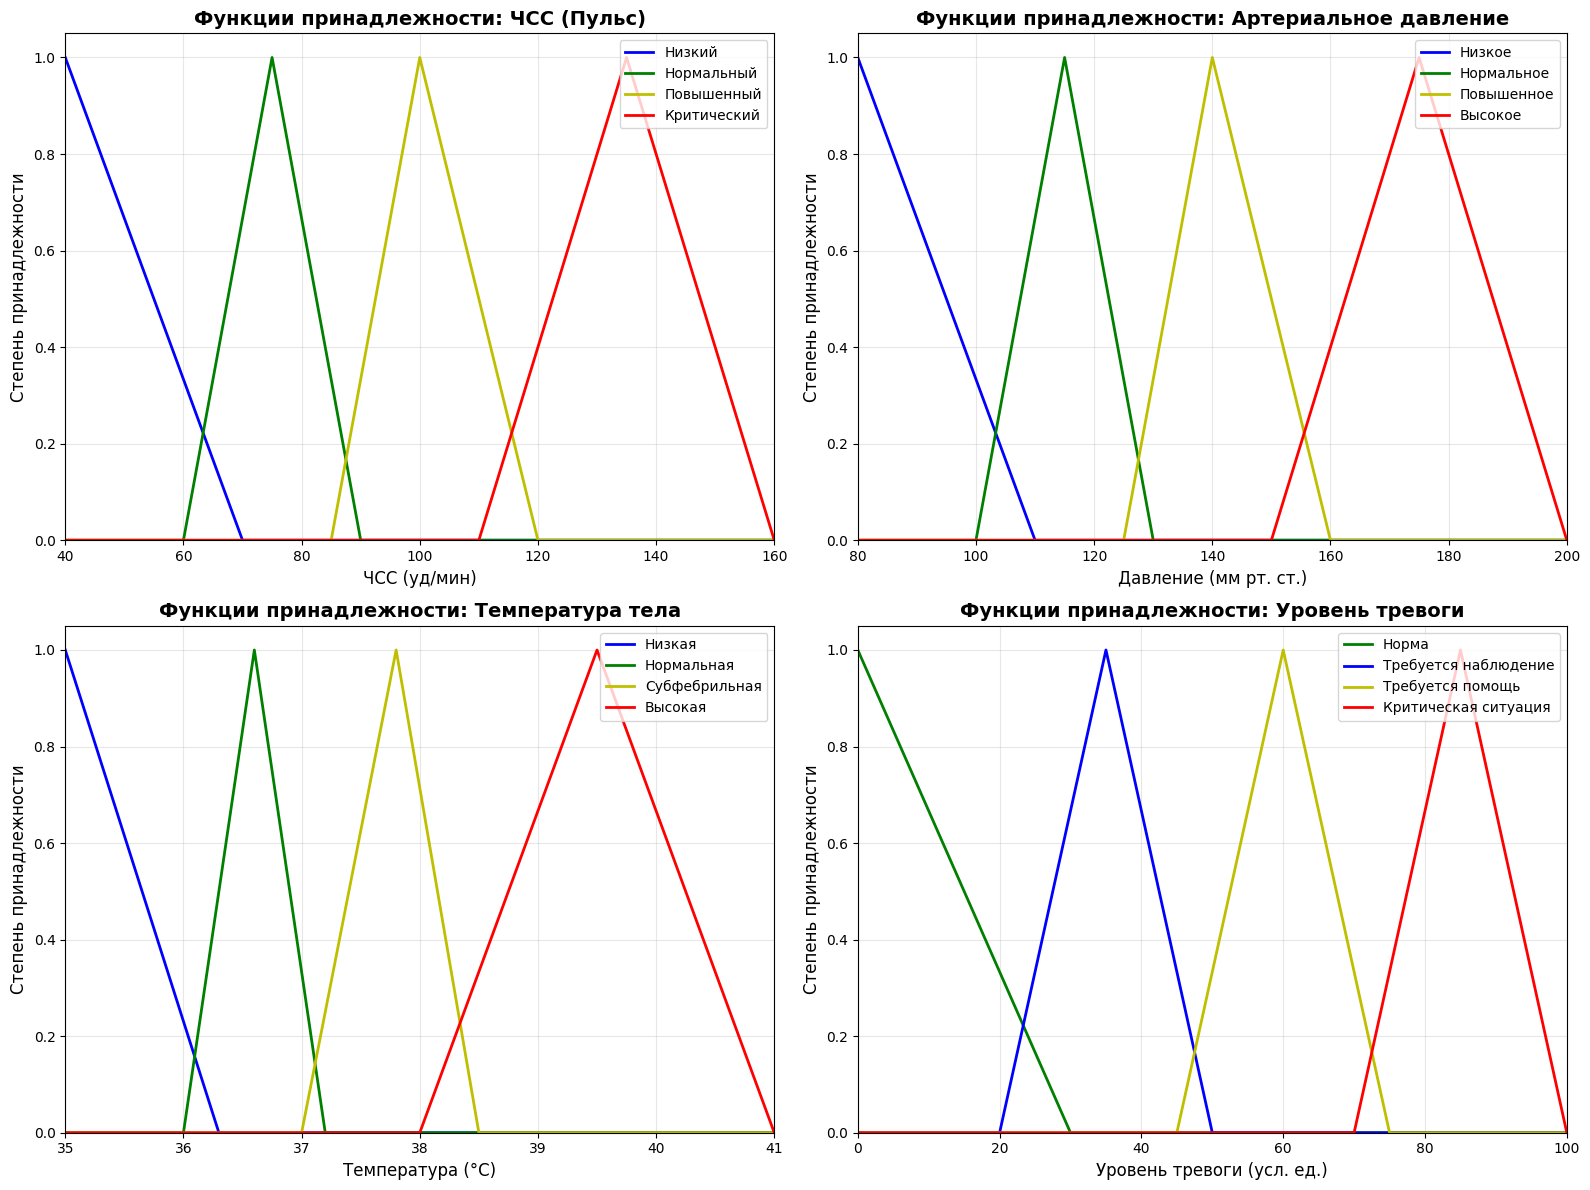

In [64]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Настройка для отображения графиков
plt.rcParams['figure.figsize'] = (16, 12)

# Создание входных переменных
heart_rate = ctrl.Antecedent(np.arange(40, 161, 1), 'heart_rate')
blood_pressure = ctrl.Antecedent(np.arange(80, 201, 1), 'blood_pressure')
body_temperature = ctrl.Antecedent(np.arange(35, 41.1, 0.1), 'body_temperature')

# Создание выходной переменной
alert_level = ctrl.Consequent(np.arange(0, 101, 1), 'alert_level')

# Определение функций принадлежности для ЧСС (пульса)
heart_rate['HeartRate_low_NB'] = fuzz.trimf(heart_rate.universe, [40, 40, 70])
heart_rate['HeartRate_normal_Z'] = fuzz.trimf(heart_rate.universe, [60, 75, 90])
heart_rate['HeartRate_elevated_PS'] = fuzz.trimf(heart_rate.universe, [85, 100, 120])
heart_rate['HeartRate_critical'] = fuzz.trimf(heart_rate.universe, [110, 135, 160])

# Определение функций принадлежности для артериального давления
blood_pressure['BloodPressure_low'] = fuzz.trimf(blood_pressure.universe, [80, 80, 110])
blood_pressure['BloodPressure_normal'] = fuzz.trimf(blood_pressure.universe, [100, 115, 130])
blood_pressure['BloodPressure_elevated'] = fuzz.trimf(blood_pressure.universe, [125, 140, 160])
blood_pressure['BloodPressure_high'] = fuzz.trimf(blood_pressure.universe, [150, 175, 200])

# Определение функций принадлежности для температуры тела
body_temperature['BodyTemperature_low'] = fuzz.trimf(body_temperature.universe, [35.0, 35.0, 36.3])
body_temperature['BodyTemperature_normal'] = fuzz.trimf(body_temperature.universe, [36.0, 36.6, 37.2])
body_temperature['BodyTemperature_subfever'] = fuzz.trimf(body_temperature.universe, [37.0, 37.8, 38.5])
body_temperature['BodyTemperature_high'] = fuzz.trimf(body_temperature.universe, [38.0, 39.5, 41.0])

# Определение функций принадлежности для уровня тревоги
alert_level['AlertLevel_normal'] = fuzz.trimf(alert_level.universe, [0, 0, 30])
alert_level['AlertLevel_monitoring'] = fuzz.trimf(alert_level.universe, [20, 35, 50])
alert_level['AlertLevel_assistance'] = fuzz.trimf(alert_level.universe, [45, 60, 75])
alert_level['AlertLevel_critical'] = fuzz.trimf(alert_level.universe, [70, 85, 100])

# Визуализация функций принадлежности
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: ЧСС (Пульс)
ax = axes[0, 0]
ax.plot(heart_rate.universe, heart_rate['HeartRate_low_NB'].mf, 'b-', linewidth=2, label='Низкий')
ax.plot(heart_rate.universe, heart_rate['HeartRate_normal_Z'].mf, 'g-', linewidth=2, label='Нормальный')
ax.plot(heart_rate.universe, heart_rate['HeartRate_elevated_PS'].mf, 'y-', linewidth=2, label='Повышенный')
ax.plot(heart_rate.universe, heart_rate['HeartRate_critical'].mf, 'r-', linewidth=2, label='Критический')
ax.set_title('Функции принадлежности: ЧСС (Пульс)', fontsize=14, fontweight='bold')
ax.set_xlabel('ЧСС (уд/мин)', fontsize=12)
ax.set_ylabel('Степень принадлежности', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([40, 160])
ax.set_ylim([0, 1.05])

# График 2: Артериальное давление
ax = axes[0, 1]
ax.plot(blood_pressure.universe, blood_pressure['BloodPressure_low'].mf, 'b-', linewidth=2, label='Низкое')
ax.plot(blood_pressure.universe, blood_pressure['BloodPressure_normal'].mf, 'g-', linewidth=2, label='Нормальное')
ax.plot(blood_pressure.universe, blood_pressure['BloodPressure_elevated'].mf, 'y-', linewidth=2, label='Повышенное')
ax.plot(blood_pressure.universe, blood_pressure['BloodPressure_high'].mf, 'r-', linewidth=2, label='Высокое')
ax.set_title('Функции принадлежности: Артериальное давление', fontsize=14, fontweight='bold')
ax.set_xlabel('Давление (мм рт. ст.)', fontsize=12)
ax.set_ylabel('Степень принадлежности', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([80, 200])
ax.set_ylim([0, 1.05])

# График 3: Температура тела
ax = axes[1, 0]
ax.plot(body_temperature.universe, body_temperature['BodyTemperature_low'].mf, 'b-', linewidth=2, label='Низкая')
ax.plot(body_temperature.universe, body_temperature['BodyTemperature_normal'].mf, 'g-', linewidth=2, label='Нормальная')
ax.plot(body_temperature.universe, body_temperature['BodyTemperature_subfever'].mf, 'y-', linewidth=2, label='Субфебрильная')
ax.plot(body_temperature.universe, body_temperature['BodyTemperature_high'].mf, 'r-', linewidth=2, label='Высокая')
ax.set_title('Функции принадлежности: Температура тела', fontsize=14, fontweight='bold')
ax.set_xlabel('Температура (°C)', fontsize=12)
ax.set_ylabel('Степень принадлежности', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([35, 41])
ax.set_ylim([0, 1.05])

# График 4: Уровень тревоги (выходная переменная)
ax = axes[1, 1]
ax.plot(alert_level.universe, alert_level['AlertLevel_normal'].mf, 'g-', linewidth=2, label='Норма')
ax.plot(alert_level.universe, alert_level['AlertLevel_monitoring'].mf, 'b-', linewidth=2, label='Требуется наблюдение')
ax.plot(alert_level.universe, alert_level['AlertLevel_assistance'].mf, 'y-', linewidth=2, label='Требуется помощь')
ax.plot(alert_level.universe, alert_level['AlertLevel_critical'].mf, 'r-', linewidth=2, label='Критическая ситуация')
ax.set_title('Функции принадлежности: Уровень тревоги', fontsize=14, fontweight='bold')
ax.set_xlabel('Уровень тревоги (усл. ед.)', fontsize=12)
ax.set_ylabel('Степень принадлежности', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 100])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('./membership_functions.png', dpi=300, bbox_inches='tight')
plt.show()

In [65]:
# Пример фаззификации конкретных значений
print("\n" + "="*70)
print("ПРИМЕР ФАЗЗИФИКАЦИИ")
print("="*70)

# Входные данные пациента
test_heart_rate = 95  # уд/мин
test_blood_pressure = 145  # мм рт. ст.
test_body_temperature = 37.8  # °C

print(f"\nВходные параметры пациента:")
print(f"  ЧСС (Пульс): {test_heart_rate} уд/мин")
print(f"  Артериальное давление: {test_blood_pressure} мм рт. ст.")
print(f"  Температура тела: {test_body_temperature} °C")

# Вычисление степеней принадлежности для ЧСС
print(f"\n{'─'*70}")
print(f"Степени принадлежности для ЧСС = {test_heart_rate} уд/мин:")
print(f"{'─'*70}")
hr_low = fuzz.interp_membership(heart_rate.universe, heart_rate['HeartRate_low_NB'].mf, test_heart_rate)
hr_normal = fuzz.interp_membership(heart_rate.universe, heart_rate['HeartRate_normal_Z'].mf, test_heart_rate)
hr_elevated = fuzz.interp_membership(heart_rate.universe, heart_rate['HeartRate_elevated_PS'].mf, test_heart_rate)
hr_critical = fuzz.interp_membership(heart_rate.universe, heart_rate['HeartRate_critical'].mf, test_heart_rate)

print(f"  Низкий:      {hr_low:.4f} {'█' * int(hr_low * 50)}")
print(f"  Нормальный:  {hr_normal:.4f} {'█' * int(hr_normal * 50)}")
print(f"  Повышенный:  {hr_elevated:.4f} {'█' * int(hr_elevated * 50)}")
print(f"  Критический: {hr_critical:.4f} {'█' * int(hr_critical * 50)}")

# Вычисление степеней принадлежности для давления
print(f"\n{'─'*70}")
print(f"Степени принадлежности для Давления = {test_blood_pressure} мм рт. ст.:")
print(f"{'─'*70}")
bp_low = fuzz.interp_membership(blood_pressure.universe, blood_pressure['BloodPressure_low'].mf, test_blood_pressure)
bp_normal = fuzz.interp_membership(blood_pressure.universe, blood_pressure['BloodPressure_normal'].mf, test_blood_pressure)
bp_elevated = fuzz.interp_membership(blood_pressure.universe, blood_pressure['BloodPressure_elevated'].mf, test_blood_pressure)
bp_high = fuzz.interp_membership(blood_pressure.universe, blood_pressure['BloodPressure_high'].mf, test_blood_pressure)

print(f"  Низкое:      {bp_low:.4f} {'█' * int(bp_low * 50)}")
print(f"  Нормальное:  {bp_normal:.4f} {'█' * int(bp_normal * 50)}")
print(f"  Повышенное:  {bp_elevated:.4f} {'█' * int(bp_elevated * 50)}")
print(f"  Высокое:     {bp_high:.4f} {'█' * int(bp_high * 50)}")

# Вычисление степеней принадлежности для температуры
print(f"\n{'─'*70}")
print(f"Степени принадлежности для Температуры = {test_body_temperature} °C:")
print(f"{'─'*70}")
temp_low = fuzz.interp_membership(body_temperature.universe, body_temperature['BodyTemperature_low'].mf, test_body_temperature)
temp_normal = fuzz.interp_membership(body_temperature.universe, body_temperature['BodyTemperature_normal'].mf, test_body_temperature)
temp_subfever = fuzz.interp_membership(body_temperature.universe, body_temperature['BodyTemperature_subfever'].mf, test_body_temperature)
temp_high = fuzz.interp_membership(body_temperature.universe, body_temperature['BodyTemperature_high'].mf, test_body_temperature)

print(f"  Низкая:        {temp_low:.4f} {'█' * int(temp_low * 50)}")
print(f"  Нормальная:    {temp_normal:.4f} {'█' * int(temp_normal * 50)}")
print(f"  Субфебрильная: {temp_subfever:.4f} {'█' * int(temp_subfever * 50)}")
print(f"  Высокая:       {temp_high:.4f} {'█' * int(temp_high * 50)}")

print("\n" + "="*70)


ПРИМЕР ФАЗЗИФИКАЦИИ

Входные параметры пациента:
  ЧСС (Пульс): 95 уд/мин
  Артериальное давление: 145 мм рт. ст.
  Температура тела: 37.8 °C

──────────────────────────────────────────────────────────────────────
Степени принадлежности для ЧСС = 95 уд/мин:
──────────────────────────────────────────────────────────────────────
  Низкий:      0.0000 
  Нормальный:  0.0000 
  Повышенный:  0.6667 █████████████████████████████████
  Критический: 0.0000 

──────────────────────────────────────────────────────────────────────
Степени принадлежности для Давления = 145 мм рт. ст.:
──────────────────────────────────────────────────────────────────────
  Низкое:      0.0000 
  Нормальное:  0.0000 
  Повышенное:  0.7500 █████████████████████████████████████
  Высокое:     0.0000 

──────────────────────────────────────────────────────────────────────
Степени принадлежности для Температуры = 37.8 °C:
──────────────────────────────────────────────────────────────────────
  Низкая:        0.0000 
 

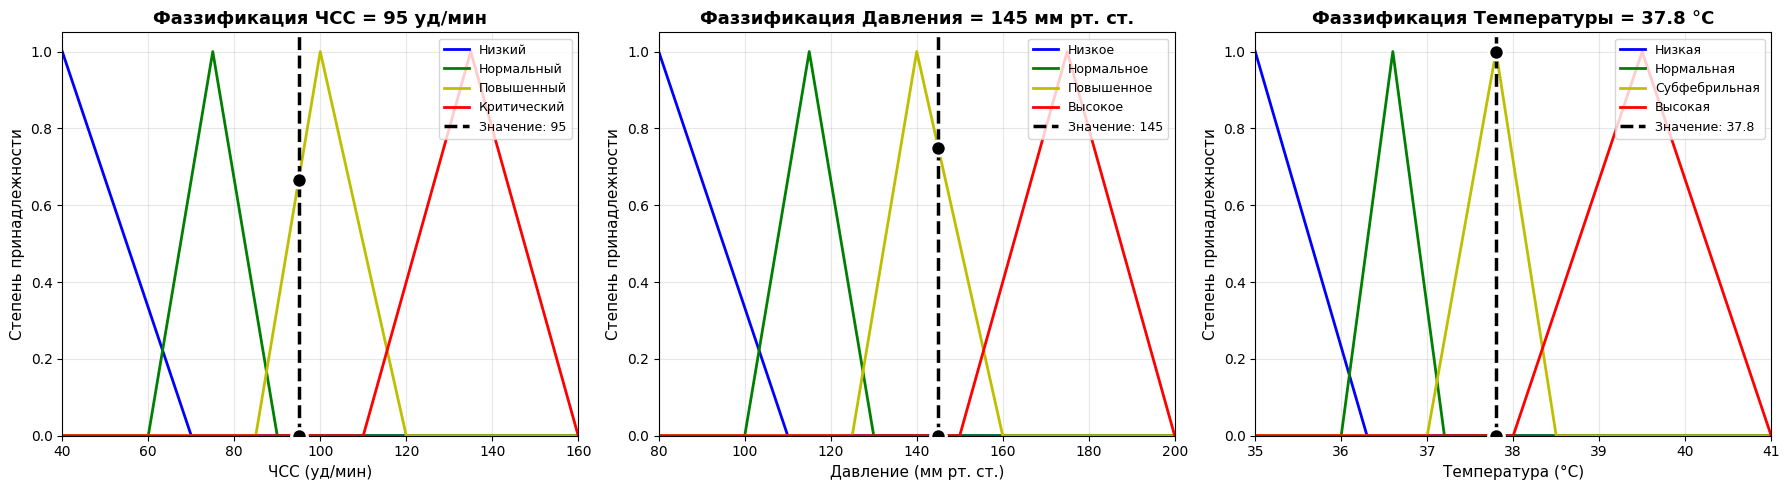

In [66]:
# Визуализация фаззификации на отдельном графике
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

# График фаззификации ЧСС
ax = axes2[0]
ax.plot(heart_rate.universe, heart_rate['HeartRate_low_NB'].mf, 'b-', linewidth=2, label='Низкий')
ax.plot(heart_rate.universe, heart_rate['HeartRate_normal_Z'].mf, 'g-', linewidth=2, label='Нормальный')
ax.plot(heart_rate.universe, heart_rate['HeartRate_elevated_PS'].mf, 'y-', linewidth=2, label='Повышенный')
ax.plot(heart_rate.universe, heart_rate['HeartRate_critical'].mf, 'r-', linewidth=2, label='Критический')
ax.axvline(x=test_heart_rate, color='black', linestyle='--', linewidth=2.5,
           label=f'Значение: {test_heart_rate}')
ax.scatter([test_heart_rate]*4, [hr_low, hr_normal, hr_elevated, hr_critical],
           color='black', s=120, zorder=5, marker='o', edgecolors='white', linewidths=2)
ax.set_title(f'Фаззификация ЧСС = {test_heart_rate} уд/мин', fontsize=13, fontweight='bold')
ax.set_xlabel('ЧСС (уд/мин)', fontsize=11)
ax.set_ylabel('Степень принадлежности', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([40, 160])
ax.set_ylim([0, 1.05])

# График фаззификации давления
ax = axes2[1]
ax.plot(blood_pressure.universe, blood_pressure['BloodPressure_low'].mf, 'b-', linewidth=2, label='Низкое')
ax.plot(blood_pressure.universe, blood_pressure['BloodPressure_normal'].mf, 'g-', linewidth=2, label='Нормальное')
ax.plot(blood_pressure.universe, blood_pressure['BloodPressure_elevated'].mf, 'y-', linewidth=2, label='Повышенное')
ax.plot(blood_pressure.universe, blood_pressure['BloodPressure_high'].mf, 'r-', linewidth=2, label='Высокое')
ax.axvline(x=test_blood_pressure, color='black', linestyle='--', linewidth=2.5,
           label=f'Значение: {test_blood_pressure}')
ax.scatter([test_blood_pressure]*4, [bp_low, bp_normal, bp_elevated, bp_high],
           color='black', s=120, zorder=5, marker='o', edgecolors='white', linewidths=2)
ax.set_title(f'Фаззификация Давления = {test_blood_pressure} мм рт. ст.', fontsize=13, fontweight='bold')
ax.set_xlabel('Давление (мм рт. ст.)', fontsize=11)
ax.set_ylabel('Степень принадлежности', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([80, 200])
ax.set_ylim([0, 1.05])

# График фаззификации температуры
ax = axes2[2]
ax.plot(body_temperature.universe, body_temperature['BodyTemperature_low'].mf, 'b-', linewidth=2, label='Низкая')
ax.plot(body_temperature.universe, body_temperature['BodyTemperature_normal'].mf, 'g-', linewidth=2, label='Нормальная')
ax.plot(body_temperature.universe, body_temperature['BodyTemperature_subfever'].mf, 'y-', linewidth=2, label='Субфебрильная')
ax.plot(body_temperature.universe, body_temperature['BodyTemperature_high'].mf, 'r-', linewidth=2, label='Высокая')
ax.axvline(x=test_body_temperature, color='black', linestyle='--', linewidth=2.5,
           label=f'Значение: {test_body_temperature}')
ax.scatter([test_body_temperature]*4, [temp_low, temp_normal, temp_subfever, temp_high],
           color='black', s=120, zorder=5, marker='o', edgecolors='white', linewidths=2)
ax.set_title(f'Фаззификация Температуры = {test_body_temperature} °C', fontsize=13, fontweight='bold')
ax.set_xlabel('Температура (°C)', fontsize=11)
ax.set_ylabel('Степень принадлежности', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([35, 41])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('./fuzzification_example.png', dpi=300, bbox_inches='tight')
plt.show()

In [76]:
# 4. Активизация и агрегирование правил нечетких продукций

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

print("=" * 80)
print("4. АКТИВИЗАЦИЯ И АГРЕГИРОВАНИЕ ПРАВИЛ НЕЧЕТКИХ ПРОДУКЦИЙ")
print("=" * 80)

# Тестовые входные данные пациента
test_heart_rate = 95  # уд/мин (повышенный)
test_blood_pressure = 145  # мм рт. ст. (повышенное)
test_body_temperature = 37.8  # °C (субфебрильная)

print(f"\nВходные параметры пациента:")
print(f"  ЧСС (Пульс): {test_heart_rate} уд/мин")
print(f"  Артериальное давление: {test_blood_pressure} мм рт. ст.")
print(f"  Температура тела: {test_body_temperature} °C")

# Задание входных значений
alert_simulation.input['heart_rate'] = test_heart_rate
alert_simulation.input['blood_pressure'] = test_blood_pressure
alert_simulation.input['body_temperature'] = test_body_temperature

# ============================================================================
# ЭТАП 1: ФАЗЗИФИКАЦИЯ
# ============================================================================
print("\n" + "-" * 80)
print("ЭТАП 1: ФАЗЗИФИКАЦИЯ")
print("-" * 80)

# Вычисление степеней принадлежности для ЧСС
hr_low = fuzz.interp_membership(heart_rate.universe, heart_rate['HeartRate_low_NB'].mf, test_heart_rate)
hr_normal = fuzz.interp_membership(heart_rate.universe, heart_rate['HeartRate_normal_Z'].mf, test_heart_rate)
hr_elevated = fuzz.interp_membership(heart_rate.universe, heart_rate['HeartRate_elevated_PS'].mf, test_heart_rate)
hr_critical = fuzz.interp_membership(heart_rate.universe, heart_rate['HeartRate_critical'].mf, test_heart_rate)

print(f"\nЧСС = {test_heart_rate} уд/мин:")
print(f"  μ(HeartRate_low_NB) = {hr_low:.4f}")
print(f"  μ(HeartRate_normal_Z) = {hr_normal:.4f}")
print(f"  μ(HeartRate_elevated_PS) = {hr_elevated:.4f}")
print(f"  μ(HeartRate_critical) = {hr_critical:.4f}")

# Вычисление степеней принадлежности для давления
bp_low = fuzz.interp_membership(blood_pressure.universe, blood_pressure['BloodPressure_low'].mf, test_blood_pressure)
bp_normal = fuzz.interp_membership(blood_pressure.universe, blood_pressure['BloodPressure_normal'].mf,
                                   test_blood_pressure)
bp_elevated = fuzz.interp_membership(blood_pressure.universe, blood_pressure['BloodPressure_elevated'].mf,
                                     test_blood_pressure)
bp_high = fuzz.interp_membership(blood_pressure.universe, blood_pressure['BloodPressure_high'].mf, test_blood_pressure)

print(f"\nДавление = {test_blood_pressure} мм рт. ст.:")
print(f"  μ(BloodPressure_low) = {bp_low:.4f}")
print(f"  μ(BloodPressure_normal) = {bp_normal:.4f}")
print(f"  μ(BloodPressure_elevated) = {bp_elevated:.4f}")
print(f"  μ(BloodPressure_high) = {bp_high:.4f}")

# Вычисление степеней принадлежности для температуры
temp_low = fuzz.interp_membership(body_temperature.universe, body_temperature['BodyTemperature_low'].mf,
                                  test_body_temperature)
temp_normal = fuzz.interp_membership(body_temperature.universe, body_temperature['BodyTemperature_normal'].mf,
                                     test_body_temperature)
temp_subfever = fuzz.interp_membership(body_temperature.universe, body_temperature['BodyTemperature_subfever'].mf,
                                       test_body_temperature)
temp_high = fuzz.interp_membership(body_temperature.universe, body_temperature['BodyTemperature_high'].mf,
                                   test_body_temperature)

print(f"\nТемпература = {test_body_temperature} °C:")
print(f"  μ(BodyTemperature_low) = {temp_low:.4f}")
print(f"  μ(BodyTemperature_normal) = {temp_normal:.4f}")
print(f"  μ(BodyTemperature_subfever) = {temp_subfever:.4f}")
print(f"  μ(BodyTemperature_high) = {temp_high:.4f}")

4. АКТИВИЗАЦИЯ И АГРЕГИРОВАНИЕ ПРАВИЛ НЕЧЕТКИХ ПРОДУКЦИЙ

Входные параметры пациента:
  ЧСС (Пульс): 95 уд/мин
  Артериальное давление: 145 мм рт. ст.
  Температура тела: 37.8 °C

--------------------------------------------------------------------------------
ЭТАП 1: ФАЗЗИФИКАЦИЯ
--------------------------------------------------------------------------------

ЧСС = 95 уд/мин:
  μ(HeartRate_low_NB) = 0.0000
  μ(HeartRate_normal_Z) = 0.0000
  μ(HeartRate_elevated_PS) = 0.6667
  μ(HeartRate_critical) = 0.0000

Давление = 145 мм рт. ст.:
  μ(BloodPressure_low) = 0.0000
  μ(BloodPressure_normal) = 0.0000
  μ(BloodPressure_elevated) = 0.7500
  μ(BloodPressure_high) = 0.0000

Температура = 37.8 °C:
  μ(BodyTemperature_low) = 0.0000
  μ(BodyTemperature_normal) = 0.0000
  μ(BodyTemperature_subfever) = 1.0000
  μ(BodyTemperature_high) = 0.0000


In [69]:
# ============================================================================
# ЭТАП 2: АКТИВИЗАЦИЯ ПРАВИЛ
# ============================================================================
print("\n" + "-" * 80)
print("ЭТАП 2: АКТИВИЗАЦИЯ ПРАВИЛ (метод min)")
print("-" * 80)

# 

# Правило 11: ЕСЛИ ЧСС=elevated И Давление=elevated И Температура=subfever ТО Тревога=assistance
activation_rule11 = min(hr_elevated, bp_elevated, temp_subfever)
print(f"\nПравило 11:")
print(f"  ЕСЛИ ЧСС=elevated_PS({hr_elevated:.4f}) И Давление=elevated({bp_elevated:.4f})")
print(f"       И Температура=subfever({temp_subfever:.4f})")
print(f"  ТО Тревога=assistance")
print(
    f"  Степень активизации: min({hr_elevated:.4f}, {bp_elevated:.4f}, {temp_subfever:.4f}) = {activation_rule11:.4f}")

# Правило 10: ЕСЛИ ЧСС=elevated И Давление=normal И Температура=subfever ТО Тревога=monitoring
activation_rule10 = min(hr_elevated, bp_normal, temp_subfever)
print(f"\nПравило 10:")
print(f"  ЕСЛИ ЧСС=elevated_PS({hr_elevated:.4f}) И Давление=normal({bp_normal:.4f})")
print(f"       И Температура=subfever({temp_subfever:.4f})")
print(f"  ТО Тревога=monitoring")
print(f"  Степень активизации: min({hr_elevated:.4f}, {bp_normal:.4f}, {temp_subfever:.4f}) = {activation_rule10:.4f}")


--------------------------------------------------------------------------------
ЭТАП 2: АКТИВИЗАЦИЯ ПРАВИЛ (метод min)
--------------------------------------------------------------------------------

Правило 11:
  ЕСЛИ ЧСС=elevated_PS(0.6667) И Давление=elevated(0.7500)
       И Температура=subfever(1.0000)
  ТО Тревога=assistance
  Степень активизации: min(0.6667, 0.7500, 1.0000) = 0.6667

Правило 10:
  ЕСЛИ ЧСС=elevated_PS(0.6667) И Давление=normal(0.0000)
       И Температура=subfever(1.0000)
  ТО Тревога=monitoring
  Степень активизации: min(0.6667, 0.0000, 1.0000) = 0.0000



--------------------------------------------------------------------------------
ЭТАП 3: АГРЕГИРОВАНИЕ (метод max)
--------------------------------------------------------------------------------

Агрегирование всех активированных правил методом максимума (OR)
Результирующее значение уровня тревоги: 60.00


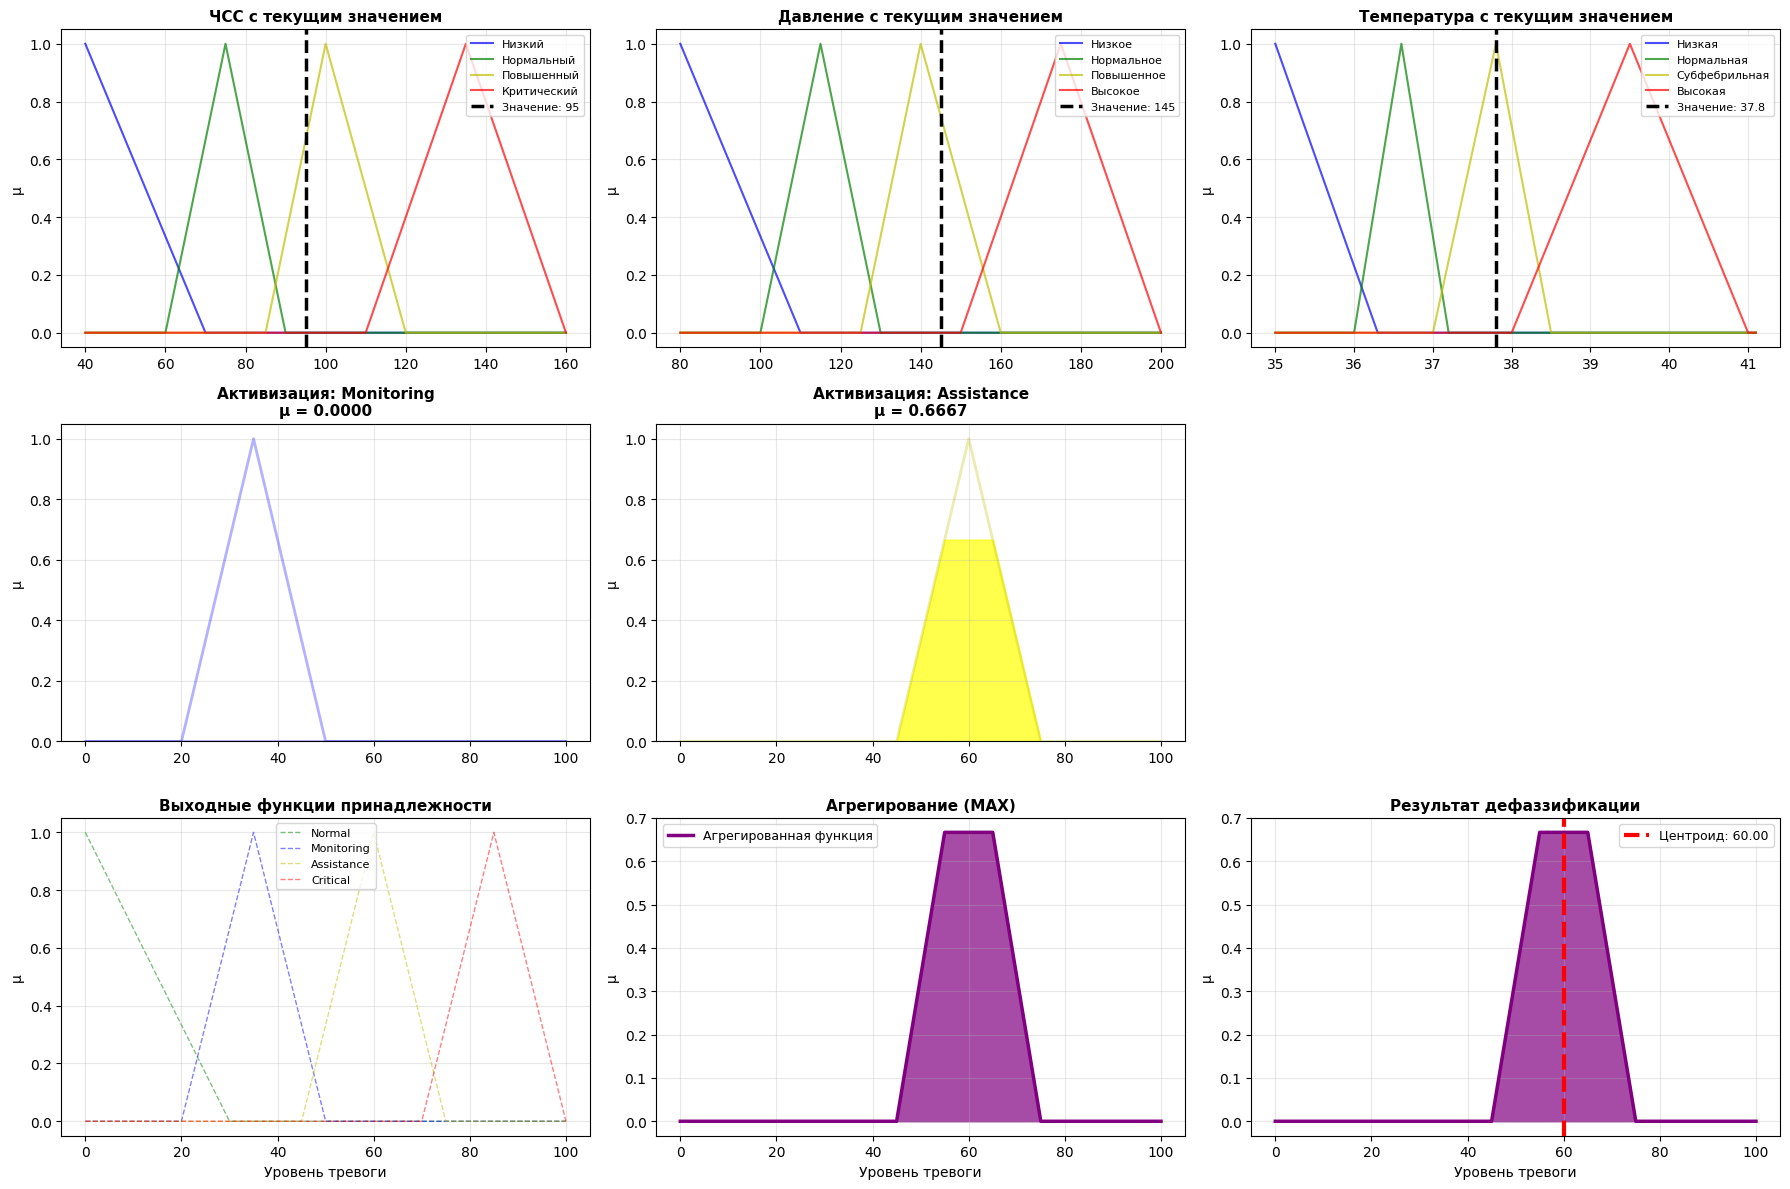

In [70]:
# ============================================================================
# ЭТАП 3: АГРЕГИРОВАНИЕ (метод max)
# ============================================================================
print("\n" + "-" * 80)
print("ЭТАП 3: АГРЕГИРОВАНИЕ (метод max)")
print("-" * 80)

# Выполнение вычислений
alert_simulation.compute()
output_value = alert_simulation.output['alert_level']

print(f"\nАгрегирование всех активированных правил методом максимума (OR)")
print(f"Результирующее значение уровня тревоги: {output_value:.2f}")

# Создание агрегированной функции принадлежности вручную для визуализации
aggregated = np.zeros_like(alert_level.universe)

# Активируем правило 10 (monitoring)
activated_monitoring = np.fmin(activation_rule10, alert_level['AlertLevel_monitoring'].mf)
aggregated = np.fmax(aggregated, activated_monitoring)

# Активируем правило 11 (assistance)
activated_assistance = np.fmin(activation_rule11, alert_level['AlertLevel_assistance'].mf)
aggregated = np.fmax(aggregated, activated_assistance)

# ============================================================================
# ВИЗУАЛИЗАЦИЯ
# ============================================================================
fig = plt.figure(figsize=(18, 12))

# График 1-3: Входные переменные с текущими значениями
ax1 = plt.subplot(3, 3, 1)
ax1.plot(heart_rate.universe, heart_rate['HeartRate_low_NB'].mf, 'b-', linewidth=1.5, alpha=0.7, label='Низкий')
ax1.plot(heart_rate.universe, heart_rate['HeartRate_normal_Z'].mf, 'g-', linewidth=1.5, alpha=0.7, label='Нормальный')
ax1.plot(heart_rate.universe, heart_rate['HeartRate_elevated_PS'].mf, 'y-', linewidth=1.5, alpha=0.7,
         label='Повышенный')
ax1.plot(heart_rate.universe, heart_rate['HeartRate_critical'].mf, 'r-', linewidth=1.5, alpha=0.7, label='Критический')
ax1.axvline(test_heart_rate, color='black', linewidth=2.5, linestyle='--', label=f'Значение: {test_heart_rate}')
ax1.set_title('ЧСС с текущим значением', fontweight='bold', fontsize=11)
ax1.set_ylabel('μ', fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(3, 3, 2)
ax2.plot(blood_pressure.universe, blood_pressure['BloodPressure_low'].mf, 'b-', linewidth=1.5, alpha=0.7,
         label='Низкое')
ax2.plot(blood_pressure.universe, blood_pressure['BloodPressure_normal'].mf, 'g-', linewidth=1.5, alpha=0.7,
         label='Нормальное')
ax2.plot(blood_pressure.universe, blood_pressure['BloodPressure_elevated'].mf, 'y-', linewidth=1.5, alpha=0.7,
         label='Повышенное')
ax2.plot(blood_pressure.universe, blood_pressure['BloodPressure_high'].mf, 'r-', linewidth=1.5, alpha=0.7,
         label='Высокое')
ax2.axvline(test_blood_pressure, color='black', linewidth=2.5, linestyle='--', label=f'Значение: {test_blood_pressure}')
ax2.set_title('Давление с текущим значением', fontweight='bold', fontsize=11)
ax2.set_ylabel('μ', fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(3, 3, 3)
ax3.plot(body_temperature.universe, body_temperature['BodyTemperature_low'].mf, 'b-', linewidth=1.5, alpha=0.7,
         label='Низкая')
ax3.plot(body_temperature.universe, body_temperature['BodyTemperature_normal'].mf, 'g-', linewidth=1.5, alpha=0.7,
         label='Нормальная')
ax3.plot(body_temperature.universe, body_temperature['BodyTemperature_subfever'].mf, 'y-', linewidth=1.5, alpha=0.7,
         label='Субфебрильная')
ax3.plot(body_temperature.universe, body_temperature['BodyTemperature_high'].mf, 'r-', linewidth=1.5, alpha=0.7,
         label='Высокая')
ax3.axvline(test_body_temperature, color='black', linewidth=2.5, linestyle='--',
            label=f'Значение: {test_body_temperature}')
ax3.set_title('Температура с текущим значением', fontweight='bold', fontsize=11)
ax3.set_ylabel('μ', fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# График 4-5: Активизация отдельных правил
ax4 = plt.subplot(3, 3, 4)
monitoring_activation = np.fmin(activation_rule10, alert_level['AlertLevel_monitoring'].mf)
ax4.fill_between(alert_level.universe, 0, monitoring_activation, alpha=0.7, color='blue')
ax4.plot(alert_level.universe, alert_level['AlertLevel_monitoring'].mf, 'b-', linewidth=2, alpha=0.3)
ax4.set_title(f'Активизация: Monitoring\nμ = {activation_rule10:.4f}', fontweight='bold', fontsize=11)
ax4.set_ylabel('μ', fontsize=10)
ax4.set_ylim([0, 1.05])
ax4.grid(True, alpha=0.3)

ax5 = plt.subplot(3, 3, 5)
assistance_activation = np.fmin(activation_rule11, alert_level['AlertLevel_assistance'].mf)
ax5.fill_between(alert_level.universe, 0, assistance_activation, alpha=0.7, color='yellow')
ax5.plot(alert_level.universe, alert_level['AlertLevel_assistance'].mf, 'y-', linewidth=2, alpha=0.3)
ax5.set_title(f'Активизация: Assistance\nμ = {activation_rule11:.4f}', fontweight='bold', fontsize=11)
ax5.set_ylabel('μ', fontsize=10)
ax5.set_ylim([0, 1.05])
ax5.grid(True, alpha=0.3)

# График 6: Выходные функции принадлежности
ax6 = plt.subplot(3, 3, 7)
ax6.plot(alert_level.universe, alert_level['AlertLevel_normal'].mf, 'g--', linewidth=1, alpha=0.5, label='Normal')
ax6.plot(alert_level.universe, alert_level['AlertLevel_monitoring'].mf, 'b--', linewidth=1, alpha=0.5,
         label='Monitoring')
ax6.plot(alert_level.universe, alert_level['AlertLevel_assistance'].mf, 'y--', linewidth=1, alpha=0.5,
         label='Assistance')
ax6.plot(alert_level.universe, alert_level['AlertLevel_critical'].mf, 'r--', linewidth=1, alpha=0.5, label='Critical')
ax6.set_title('Выходные функции принадлежности', fontweight='bold', fontsize=11)
ax6.set_xlabel('Уровень тревоги', fontsize=10)
ax6.set_ylabel('μ', fontsize=10)
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# График 7: Агрегирование
ax7 = plt.subplot(3, 3, 8)
ax7.fill_between(alert_level.universe, 0, aggregated, alpha=0.7, color='purple')
ax7.plot(alert_level.universe, aggregated, 'purple', linewidth=2.5, label='Агрегированная функция')
ax7.set_title('Агрегирование (MAX)', fontweight='bold', fontsize=11)
ax7.set_xlabel('Уровень тревоги', fontsize=10)
ax7.set_ylabel('μ', fontsize=10)
ax7.legend(fontsize=9)
ax7.grid(True, alpha=0.3)

# График 8: Результат с дефаззификацией
ax8 = plt.subplot(3, 3, 9)
ax8.fill_between(alert_level.universe, 0, aggregated, alpha=0.7, color='purple')
ax8.plot(alert_level.universe, aggregated, 'purple', linewidth=2.5)
ax8.axvline(output_value, color='red', linewidth=3, linestyle='--', label=f'Центроид: {output_value:.2f}')
ax8.set_title('Результат дефаззификации', fontweight='bold', fontsize=11)
ax8.set_xlabel('Уровень тревоги', fontsize=10)
ax8.set_ylabel('μ', fontsize=10)
ax8.legend(fontsize=9)
ax8.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./activation_and_aggregation.png', dpi=300, bbox_inches='tight')
plt.show()

In [71]:
# Интерпретация результата
print(f"\n{'=' * 80}")
print(f"РЕЗУЛЬТАТ")
print(f"{'=' * 80}")
print(f"\nУровень тревоги: {output_value:.2f}")

if output_value <= 30:
    interpretation = "НОРМА - Все показатели в пределах нормы"
elif output_value <= 50:
    interpretation = "ТРЕБУЕТСЯ НАБЛЮДЕНИЕ - Небольшие отклонения от нормы"
elif output_value <= 75:
    interpretation = "ТРЕБУЕТСЯ ПОМОЩЬ - Необходима медицинская помощь"
else:
    interpretation = "КРИТИЧЕСКАЯ СИТУАЦИЯ - Требуется немедленное вмешательство"

print(f"Интерпретация: {interpretation}")
print(f"\n{'=' * 80}")


РЕЗУЛЬТАТ

Уровень тревоги: 60.00
Интерпретация: ТРЕБУЕТСЯ ПОМОЩЬ - Необходима медицинская помощь



In [77]:
# 5. Дефаззификация различными методами

import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

print("\n" + "=" * 80)
print("5. ДЕФАЗЗИФИКАЦИЯ РАЗЛИЧНЫМИ МЕТОДАМИ")
print("=" * 80)

# Используем агрегированную функцию из предыдущего блока
print(f"\nВходные параметры пациента:")
print(f"  ЧСС (Пульс): {test_heart_rate} уд/мин")
print(f"  Артериальное давление: {test_blood_pressure} мм рт. ст.")
print(f"  Температура тела: {test_body_temperature} °C")

# ============================================================================
# МЕТОДЫ ДЕФАЗЗИФИКАЦИИ
# ============================================================================

# 1. ЦЕНТР ТЯЖЕСТИ (CENTROID / CENTER OF AREA)
centroid = fuzz.defuzz(alert_level.universe, aggregated, 'centroid')
print(f"\n1. ЦЕНТР ТЯЖЕСТИ (Centroid / Center of Area - COA):")
print(f"   Формула: x_COG = Σ(μ(x) * x) / Σ(μ(x))")
print(f"   Результат: {centroid:.4f}")

# 2. БИССЕКТОР (BISECTOR)
bisector = fuzz.defuzz(alert_level.universe, aggregated, 'bisector')
print(f"\n2. БИССЕКТОР (Bisector):")
print(f"   Описание: Делит площадь под функцией на две равные части")
print(f"   Результат: {bisector:.4f}")

# 3. СРЕДНЕЕ МАКСИМУМОВ (MEAN OF MAXIMUM)
mom = fuzz.defuzz(alert_level.universe, aggregated, 'mom')
print(f"\n3. СРЕДНЕЕ МАКСИМУМОВ (Mean of Maximum - MOM):")
print(f"   Описание: Среднее значение всех точек с максимальной степенью принадлежности")
print(f"   Результат: {mom:.4f}")

# 4. ЛЕВОЕ МОДАЛЬНОЕ ЗНАЧЕНИЕ (SMALLEST OF MAXIMUM)
som = fuzz.defuzz(alert_level.universe, aggregated, 'som')
print(f"\n4. ЛЕВОЕ МОДАЛЬНОЕ ЗНАЧЕНИЕ (Smallest of Maximum - SOM):")
print(f"   Описание: Минимальное значение из точек с максимальной степенью принадлежности")
print(f"   Результат: {som:.4f}")

# 5. ПРАВОЕ МОДАЛЬНОЕ ЗНАЧЕНИЕ (LARGEST OF MAXIMUM)
lom = fuzz.defuzz(alert_level.universe, aggregated, 'lom')
print(f"\n5. ПРАВОЕ МОДАЛЬНОЕ ЗНАЧЕНИЕ (Largest of Maximum - LOM):")
print(f"   Описание: Максимальное значение из точек с максимальной степенью принадлежности")
print(f"   Результат: {lom:.4f}")


5. ДЕФАЗЗИФИКАЦИЯ РАЗЛИЧНЫМИ МЕТОДАМИ

Входные параметры пациента:
  ЧСС (Пульс): 95 уд/мин
  Артериальное давление: 145 мм рт. ст.
  Температура тела: 37.8 °C

1. ЦЕНТР ТЯЖЕСТИ (Centroid / Center of Area - COA):
   Формула: x_COG = Σ(μ(x) * x) / Σ(μ(x))
   Результат: 60.0000

2. БИССЕКТОР (Bisector):
   Описание: Делит площадь под функцией на две равные части
   Результат: 60.0000

3. СРЕДНЕЕ МАКСИМУМОВ (Mean of Maximum - MOM):
   Описание: Среднее значение всех точек с максимальной степенью принадлежности
   Результат: 60.0000

4. ЛЕВОЕ МОДАЛЬНОЕ ЗНАЧЕНИЕ (Smallest of Maximum - SOM):
   Описание: Минимальное значение из точек с максимальной степенью принадлежности
   Результат: 55.0000

5. ПРАВОЕ МОДАЛЬНОЕ ЗНАЧЕНИЕ (Largest of Maximum - LOM):
   Описание: Максимальное значение из точек с максимальной степенью принадлежности
   Результат: 65.0000


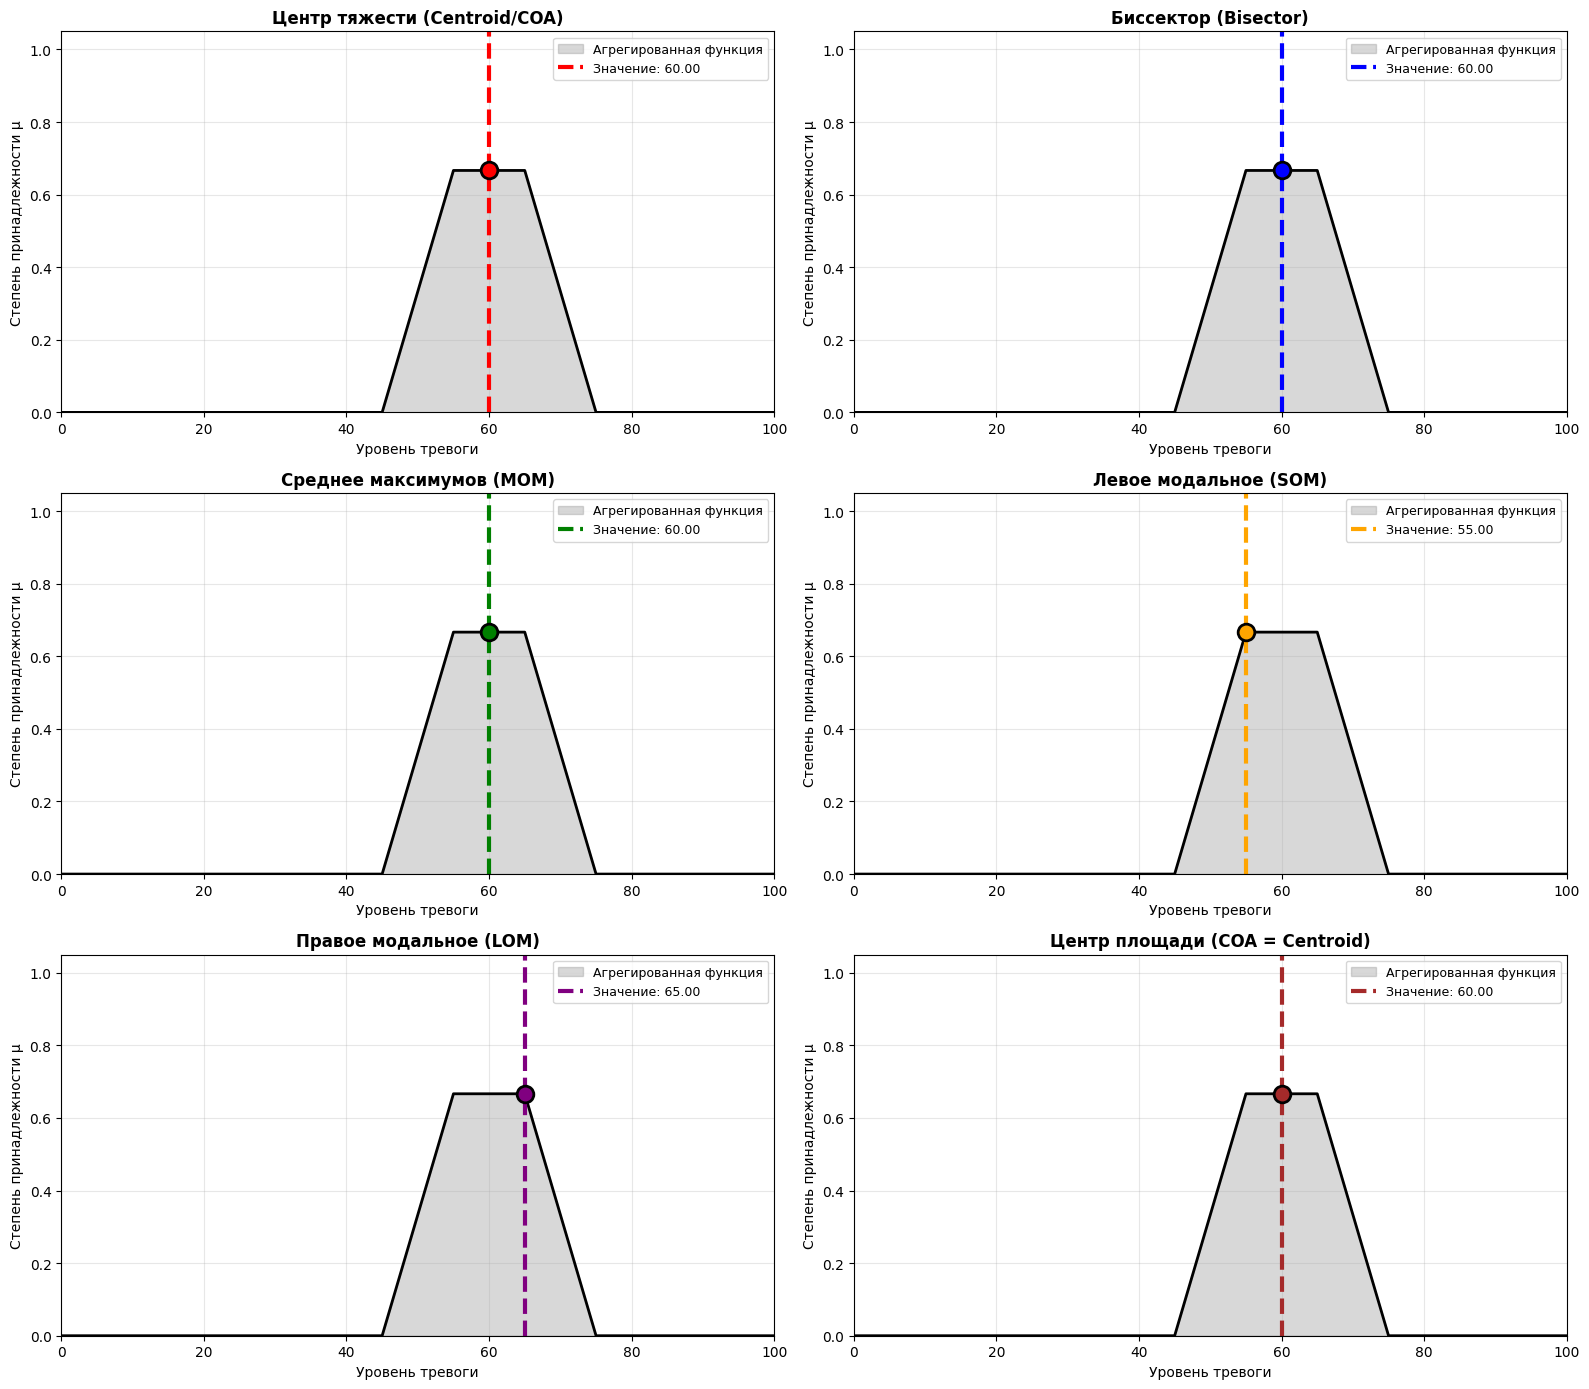

In [74]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ ВСЕХ МЕТОДОВ
# ============================================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

methods = [
    ('centroid', centroid, 'Центр тяжести (Centroid/COA)', 'red'),
    ('bisector', bisector, 'Биссектор (Bisector)', 'blue'),
    ('mom', mom, 'Среднее максимумов (MOM)', 'green'),
    ('som', som, 'Левое модальное (SOM)', 'orange'),
    ('lom', lom, 'Правое модальное (LOM)', 'purple'),
    ('coa', centroid, 'Центр площади (COA = Centroid)', 'brown')
]

for idx, (method_name, value, title, color) in enumerate(methods):
    ax = axes[idx // 2, idx % 2]

    # Агрегированная функция
    ax.fill_between(alert_level.universe, 0, aggregated, alpha=0.3, color='gray', label='Агрегированная функция')
    ax.plot(alert_level.universe, aggregated, 'k-', linewidth=2)

    # Точка дефаззификации
    ax.axvline(value, color=color, linewidth=3, linestyle='--', label=f'Значение: {value:.2f}')

    # Точка на функции
    y_value = np.interp(value, alert_level.universe, aggregated)
    ax.plot(value, y_value, 'o', color=color, markersize=12, markeredgecolor='black', markeredgewidth=2)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Уровень тревоги', fontsize=10)
    ax.set_ylabel('Степень принадлежности μ', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 100])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('./defuzzification_methods.png', dpi=300, bbox_inches='tight')
plt.show()